## <font color='Blue'>Projeto Ponta a Ponta - Regressão com TensorFlow (Boston Housing)</font>

### Objetivo deste notebook
Vamos construir um modelo de **regressão** para prever o preço mediano de casas.
Regressão significa estimar um valor numérico (neste caso, preço).

### Pipeline de um projeto de IA
1. Dados
2. Pré-processamento
3. Modelo
4. Avaliação
5. Uso prático (deploy/local)

### O que você vai entender ao final
- O que são `X` (entradas) e `y` (alvo).
- Como normalizar dados para treinar melhor.
- Como montar, treinar e avaliar uma rede neural simples.
- Como usar o modelo para prever o preço de uma nova casa.

Dataset usado: **Boston Housing** (Dataset de 1970, por isso apresenta valores discrepantes com a realidade atual).
TensorFlow: https://www.tensorflow.org/

In [2]:
# Confere a versão do Python em uso no notebook.
# Isso ajuda a evitar incompatibilidades entre bibliotecas.
from platform import python_version

print('Versão do Python neste Notebook:', python_version())

Versão do Python neste Notebook: 3.13.12


In [3]:
# Instala o TensorFlow no ambiente atual do notebook.
# O parâmetro -q reduz mensagens de instalação na tela.
%pip install -q tensorflow

Note: you may need to restart the kernel to use updated packages.


In [4]:
# Reduz mensagens internas do TensorFlow para deixar a leitura mais limpa.
# 3 = mostrar apenas erros (esconde avisos e logs informativos).
%env TF_CPP_MIN_LOG_LEVEL=3

env: TF_CPP_MIN_LOG_LEVEL=3


In [5]:
# Imports principais do projeto.
# - numpy: operações numéricas
# - tensorflow: criação e treino da rede neural
# - matplotlib/seaborn: visualizações
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import datasets, layers, models
from tensorflow.keras.callbacks import EarlyStopping

print('Bibliotecas importadas com sucesso.')

I0000 00:00:1774873405.741363    1403 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774873405.751653    1403 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774873408.684272    1403 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774873408.692101    1403 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Bibliotecas importadas com sucesso.


## Carregando os dados (matéria-prima do modelo)

Nesta etapa carregamos o dataset **Boston Housing**.
Ele já vem separado em:
- `X_treino`, `y_treino`: usados para o modelo aprender.
- `X_teste`, `y_teste`: usados para verificar se o modelo generaliza bem.

Interpretação:
- `X` = variáveis de entrada (características da casa/região).
- `y` = preço mediano da casa (valor que queremos prever).

In [6]:
# Carrega o dataset Boston Housing em treino e teste.
(X_treino, y_treino), (X_teste, y_teste) = datasets.boston_housing.load_data()

print('Dataset carregado.')

Dataset carregado.


In [7]:
# Mostra o formato das matrizes e vetores.
# Exemplo de leitura: (404, 13) significa 404 casas com 13 variáveis cada.
print('Shape X_treino:', X_treino.shape)
print('Shape y_treino:', y_treino.shape)
print('Shape X_teste:', X_teste.shape)
print('Shape y_teste:', y_teste.shape)

Shape X_treino: (404, 13)
Shape y_treino: (404,)
Shape X_teste: (102, 13)
Shape y_teste: (102,)


In [8]:
# Visualiza um exemplo real de entrada e seu valor-alvo.
# Isso ajuda a conectar os dados brutos com o que o modelo vai aprender.
print('Primeira casa (13 features):', X_treino[0])
print('Preço mediano (alvo):', y_treino[0], 'mil dólares')

Primeira casa (13 features): [  1.23247   0.        8.14      0.        0.538     6.142    91.7
   3.9769    4.      307.       21.      396.9      18.72   ]
Preço mediano (alvo): 15.2 mil dólares


## Pré-processamento

A rede neural aprende melhor quando as variáveis de entrada estão em escalas parecidas.
Por isso, vamos normalizar cada coluna de `X` usando:

`valor_normalizado = (valor - media) / desvio_padrao`

Importante: usamos **somente estatísticas do treino** (média e desvio do treino).
Assim evitamos vazamento de informação do teste para o treinamento.

In [9]:
# Guardamos cópias dos dados originais (sem normalização).
# Essas cópias são úteis para simular uso real no deploy.
X_treino_bruto = X_treino.copy()
X_teste_bruto = X_teste.copy()

print('Cópias brutas salvas para uso futuro.')

Cópias brutas salvas para uso futuro.


In [10]:
# Calcula estatísticas do treino (coluna a coluna).
media = X_treino.mean(axis=0)
desvio = X_treino.std(axis=0)

# Aplica normalização no treino e no teste usando as mesmas estatísticas.
X_treino = (X_treino - media) / desvio
X_teste = (X_teste - media) / desvio

print('Normalização concluída.')
print('Primeiras 3 médias:', media[:3])
print('Primeiros 3 desvios:', desvio[:3])

Normalização concluída.
Primeiras 3 médias: [ 3.74511057 11.48019802 11.10443069]
Primeiros 3 desvios: [ 9.22929073 23.73827702  6.80287253]


## Construção do Modelo

Vamos criar uma rede neural densa com 2 camadas ocultas.
Como o problema é de regressão:
- Saída com **1 neurônio**
- Sem função de ativação na saída (valor contínuo)

Funções usadas:
- `relu` nas camadas ocultas (aprende padrões não lineares).
- `mse` como loss (erro quadrático médio).
- `mae` como métrica interpretável (erro médio absoluto).

In [11]:
# Função que monta e compila o modelo de regressão.
def cria_modelo():
    modelo_lia = models.Sequential()

    # Entrada: 13 variáveis (ou X_treino.shape[1]).
    modelo_lia.add(layers.Input(shape=(X_treino.shape[1],)))

    # Camadas ocultas para aprender relações entre variáveis e preço.
    modelo_lia.add(layers.Dense(64, activation='relu'))
    modelo_lia.add(layers.Dense(64, activation='relu'))

    # Saída: 1 valor contínuo (preço previsto).
    modelo_lia.add(layers.Dense(1))

    modelo_lia.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    return modelo_lia

In [12]:
# Cria uma instância do modelo e exibe sua arquitetura.
modelo_lia = cria_modelo()
modelo_lia.summary()

print('Modelo pronto para treinamento.')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,121 (20.00 KB)

 Trainable params: 5,121 (20.00 KB)

 Non-trainable params: 0 (0.00 B)

Modelo pronto para treinamento.


In [13]:
%%time
# EarlyStopping interrompe quando a validação para de melhorar.
# monitor='val_loss': observa erro no conjunto de validação.
# patience=20: espera 20 épocas sem melhora antes de parar.
# restore_best_weights=True: recupera os melhores pesos encontrados.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

# Treinamento:
# - epochs=300: limite máximo de épocas
# - validation_split=0.2: 20% do treino vira validação
# - batch_size=16: quantidade de exemplos por atualização de gradiente
history = modelo_lia.fit(
    X_treino,
    y_treino,
    epochs=300,
    validation_split=0.2,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0
)

print('Treinamento concluído.')
print('Épocas executadas:', len(history.history['loss']))

Treinamento concluído.
Épocas executadas: 67
CPU times: user 5.83 s, sys: 625 ms, total: 6.45 s
Wall time: 5.34 s


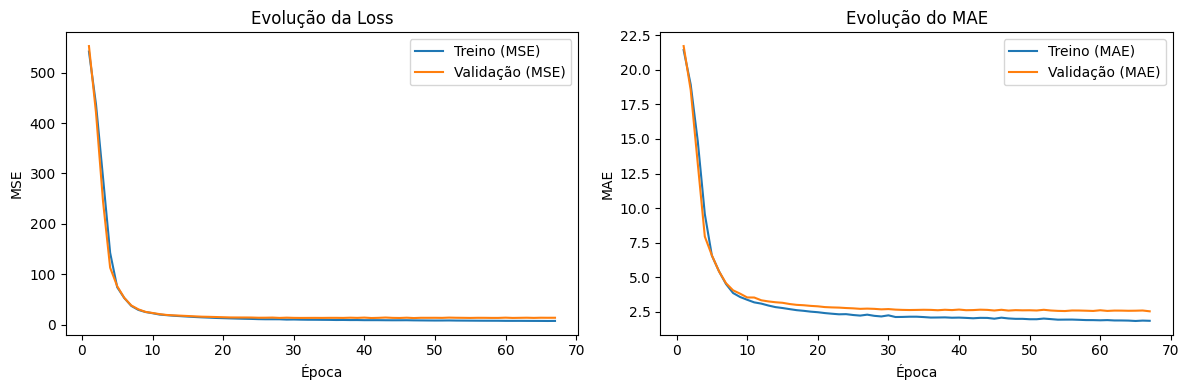

In [14]:
# Histórico do treinamento para análise de aprendizado.
hist = history.history
epocas = range(1, len(hist['loss']) + 1)

plt.figure(figsize=(12, 4))

# Gráfico 1: MSE de treino e validação ao longo das épocas.
plt.subplot(1, 2, 1)
plt.plot(epocas, hist['loss'], label='Treino (MSE)')
plt.plot(epocas, hist['val_loss'], label='Validação (MSE)')
plt.title('Evolução da Loss')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()

# Gráfico 2: MAE de treino e validação ao longo das épocas.
plt.subplot(1, 2, 2)
plt.plot(epocas, hist['mae'], label='Treino (MAE)')
plt.plot(epocas, hist['val_mae'], label='Validação (MAE)')
plt.title('Evolução do MAE')
plt.xlabel('Época')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

## Avaliação do modelo

Agora medimos desempenho no conjunto de **teste** (dados não vistos no treino).

Métricas:
- `MSE`: erro quadrático médio (penaliza mais erros grandes).
- `MAE`: erro médio absoluto (mais intuitivo).
- `RMSE`: raiz do MSE (volta para a escala do alvo).

Quanto menores essas métricas, melhor o ajuste do modelo.

In [15]:
# Avalia o modelo no conjunto de teste.
mse_teste, mae_teste = modelo_lia.evaluate(X_teste, y_teste, verbose=0)
rmse_teste = np.sqrt(mse_teste)

print(f'MSE no teste: {mse_teste:.4f}')
print(f'MAE no teste: {mae_teste:.4f}')
print(f'RMSE no teste: {rmse_teste:.4f}')

print('Interpretação: quanto menor, melhor.')

MSE no teste: 25.7142
MAE no teste: 3.2717
RMSE no teste: 5.0709
Interpretação: quanto menor, melhor.


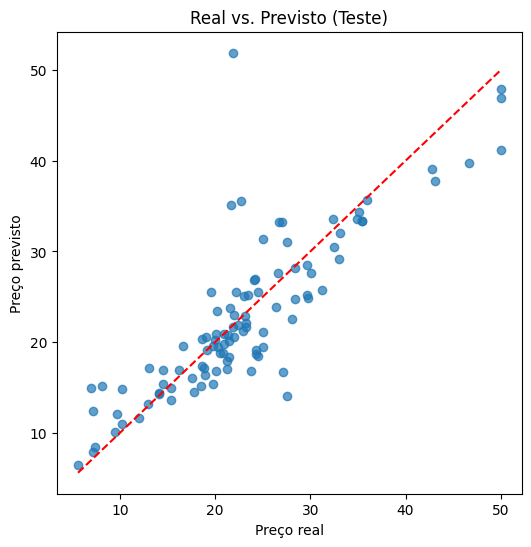

Pontos próximos da linha tracejada indicam boas previsões.


In [16]:
# Compara valores reais vs. previstos no conjunto de teste.
y_pred_teste = modelo_lia.predict(X_teste, verbose=0).flatten()

plt.figure(figsize=(6, 6))
plt.scatter(y_teste, y_pred_teste, alpha=0.7)

# Linha vermelha tracejada = previsão perfeita (real == previsto).
plt.plot([y_teste.min(), y_teste.max()], [y_teste.min(), y_teste.max()], 'r--')

plt.xlabel('Preço real')
plt.ylabel('Preço previsto')
plt.title('Real vs. Previsto (Teste)')
plt.show()

print('Pontos próximos da linha tracejada indicam boas previsões.')

## Deploy do modelo (uso prático)

Deploy, neste contexto didático, significa: **usar o modelo treinado em uma nova entrada**.
A regra principal é: qualquer nova entrada deve passar pelo mesmo pré-processamento do treino (normalização com `media` e `desvio`).

In [17]:
# Exemplo de uso com uma nova casa (aqui usamos a primeira do teste bruto).
nova_casa_bruta = X_teste_bruto[0]

# Aplica a mesma normalização usada no treinamento.
nova_casa_norm = (nova_casa_bruta - media) / desvio

# O modelo espera lote (batch), por isso adicionamos uma dimensão extra.
nova_casa_norm = np.expand_dims(nova_casa_norm, axis=0)

# Previsão do preço da nova casa.
preco_previsto = modelo_lia.predict(nova_casa_norm, verbose=0)[0, 0]
preco_real = y_teste[0]

print(f'Preço real da casa: {preco_real:.2f} mil dólares')
print(f'Preço previsto pelo modelo: {preco_previsto:.2f} mil dólares')

Preço real da casa: 7.20 mil dólares
Preço previsto pelo modelo: 7.91 mil dólares


## Exemplos prontos (1 célula por casa)

Abaixo, cada célula representa uma casa com 13 variáveis de entrada.
Fluxo em cada exemplo:
1. Mostrar imagem da casa (pasta `image`).
2. Organizar os 13 valores numéricos.
3. Normalizar com `media` e `desvio` do treino.
4. Gerar previsão de preço com o modelo.

Mapeamento das imagens:
- Casa 1 -> Image1
- Casa 2 -> Image2
- Casa 3 -> Image3
- Casa 4 -> Image4
- Casa 5 -> Image5

In [18]:
# Função auxiliar para visualizar a imagem e estimar preço de uma casa.
from PIL import Image
from IPython.display import display


def prever_exemplo(dados_casa, imagem_nome, titulo='Casa de exemplo'):
    # 1) Exibe informações básicas do exemplo atual.
    print(f'{titulo} - imagem usada: {imagem_nome}')

    # 2) Tenta abrir e mostrar a imagem da casa.
    caminho_imagem = f'image/{imagem_nome}.jpeg'
    try:
        img = Image.open(caminho_imagem)
        display(img)
    except FileNotFoundError:
        print(f'Imagem não encontrada em: {caminho_imagem}')

    # 3) Converte para array numérico e normaliza.
    entrada_bruta = np.array(dados_casa, dtype=np.float32)
    entrada_norm = (entrada_bruta - media) / desvio
    entrada_norm = np.expand_dims(entrada_norm, axis=0)

    # 4) Prediz preço com o modelo treinado.
    preco_previsto_exemplo = modelo_lia.predict(entrada_norm, verbose=0)[0, 0]

    print('Dados usados (CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD, TAX, PTRATIO, B, LSTAT):')
    print(dados_casa)
    print(f'Valor estimado: {preco_previsto_exemplo:.2f} mil dólares')

## Entendendo as 13 variáveis de entrada

A ordem das variáveis deve ser sempre a mesma:

- **CRIM**: taxa de criminalidade por cidade.
- **ZN**: proporção de terrenos residenciais grandes.
- **INDUS**: proporção de área não comercial.
- **CHAS**: faz fronteira com o rio Charles (0 = não, 1 = sim).
- **NOX**: concentração de óxidos nítricos.
- **RM**: número médio de cômodos por casa.
- **AGE**: proporção de casas antigas.
- **DIS**: distância até centros de emprego.
- **RAD**: acesso a rodovias radiais.
- **TAX**: imposto predial.
- **PTRATIO**: razão aluno/professor.
- **B**: indicador socioeconômico do dataset.
- **LSTAT**: percentual de população de menor status social.

Resumo importante:
- Essas variáveis são normalizadas com `media` e `desvio` do treino.
- A rede aprende relações entre essas entradas e o preço.
- A qualidade final é vista por métricas (MSE, MAE, RMSE) e pelo gráfico Real x Previsto.

Casa 1 - imagem usada: Image1


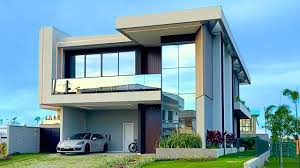

Dados usados (CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD, TAX, PTRATIO, B, LSTAT):
[0.05, 35.0, 2.5, 0, 0.42, 7.4, 30.0, 7.5, 2, 250, 16.0, 395.0, 4.2]
Valor estimado: 34.19 mil dólares


In [19]:
# Casa 1 (exemplo de valor mais alto).
# Formato da lista: [CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD, TAX, PTRATIO, B, LSTAT]
dados_casa_1 = [0.05, 35.0, 2.5, 0, 0.42, 7.4, 30.0, 7.5, 2, 250, 16.0, 395.0, 4.2]
prever_exemplo(dados_casa_1, 'Image1', titulo='Casa 1')

Casa 2 - imagem usada: Image2


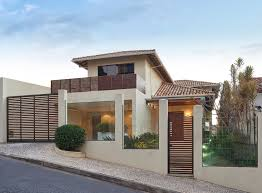

Dados usados (CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD, TAX, PTRATIO, B, LSTAT):
[0.22, 18.0, 6.0, 0, 0.48, 6.5, 55.0, 5.2, 4, 300, 17.8, 392.0, 8.5]
Valor estimado: 20.46 mil dólares


In [20]:
# Casa 2 (faixa intermediária).
# Mantemos a mesma ordem das 13 variáveis.
dados_casa_2 = [0.22, 18.0, 6.0, 0, 0.48, 6.5, 55.0, 5.2, 4, 300, 17.8, 392.0, 8.5]
prever_exemplo(dados_casa_2, 'Image2', titulo='Casa 2')

Casa 3 - imagem usada: Image3


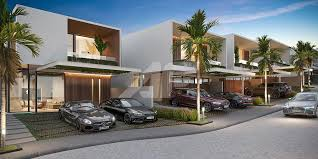

Dados usados (CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD, TAX, PTRATIO, B, LSTAT):
[3.8, 0.0, 18.0, 0, 0.67, 5.6, 88.0, 2.1, 24, 666, 20.2, 360.0, 18.0]
Valor estimado: 16.67 mil dólares


In [21]:
# Casa 3 (exemplo de valor mais baixo).
# A ordem incorreta das variáveis pode gerar previsão errada.
dados_casa_3 = [3.80, 0.0, 18.0, 0, 0.67, 5.6, 88.0, 2.1, 24, 666, 20.2, 360.0, 18.0]
prever_exemplo(dados_casa_3, 'Image3', titulo='Casa 3')

Casa 4 - imagem usada: Image4


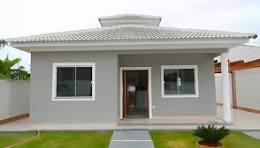

Dados usados (CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD, TAX, PTRATIO, B, LSTAT):
[0.95, 0.0, 9.9, 0, 0.54, 6.2, 72.0, 3.9, 5, 330, 18.7, 385.0, 12.0]
Valor estimado: 15.77 mil dólares


In [22]:
# Casa 4 (perfil intermediário).
dados_casa_4 = [0.95, 0.0, 9.9, 0, 0.54, 6.2, 72.0, 3.9, 5, 330, 18.7, 385.0, 12.0]
prever_exemplo(dados_casa_4, 'Image4', titulo='Casa 4')

Casa 5 - imagem usada: Image5


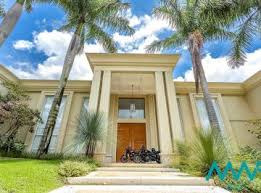

Dados usados (CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD, TAX, PTRATIO, B, LSTAT):
[0.03, 60.0, 3.2, 1, 0.4, 7.9, 25.0, 8.8, 1, 220, 15.0, 396.0, 3.0]
Valor estimado: 41.84 mil dólares


In [23]:
# Casa 5 (exemplo de valor alto).
dados_casa_5 = [0.03, 60.0, 3.2, 1, 0.40, 7.9, 25.0, 8.8, 1, 220, 15.0, 396.0, 3.0]
prever_exemplo(dados_casa_5, 'Image5', titulo='Casa 5')